In [1]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image, ImageOps, ImageFilter, ImageDraw
from diffusers import StableDiffusionInpaintPipeline, AutoencoderKL
from torch.utils.tensorboard import SummaryWriter
import datetime

state = {"current_shift": (0, 0)}

state = {"shift": (0, 0)}

def callback(pipe, step_index, timestep, callback_kwargs):
    global state
    latents = callback_kwargs["latents"]
    mask = callback_kwargs["mask"]
    image = callback_kwargs["masked_image_latents"]

    if state["shift"] != (0, 0):
        sx, sy = state["shift"]
        latents = torch.roll(latents, shifts=(-sy, -sx), dims=(-2, -1))
        mask = torch.roll(mask, shifts=(-sy, -sx), dims=(-2, -1))
        image = torch.roll(image, shifts=(-sy, -sx), dims=(-2, -1))

    if step_index < len(pipe.scheduler.timesteps) - 1:
        new_sx = torch.randint(0, latents.shape[-1], (1,)).item()
        new_sy = torch.randint(0, latents.shape[-2], (1,)).item()
        
        latents = torch.roll(latents, shifts=(new_sy, new_sx), dims=(-2, -1))
        mask = torch.roll(mask, shifts=(new_sy, new_sx), dims=(-2, -1))
        image = torch.roll(image, shifts=(new_sy, new_sx), dims=(-2, -1))

        state["shift"] = (new_sx, new_sy)
    else:
        state["shift"] = (0, 0)

    callback_kwargs["latents"] = latents
    callback_kwargs["mask"] = mask
    callback_kwargs["masked_image_latents"] = image
    return callback_kwargs

/export/home/federica.digiaimo2/miniconda3/envs/rectification/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
log_dir = "runs/esperimento_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir)

device = "cuda"
model_id = "sd-legacy/stable-diffusion-inpainting"
adapter_id = "h94/IP-Adapter"

In [3]:
vae = AutoencoderKL.from_pretrained(
    "stabilityai/sd-vae-ft-mse"
).to(device)

pipe = StableDiffusionInpaintPipeline.from_pretrained(model_id, vae=vae).to("cuda")
#pipe.vae.enable_tiling()

/export/home/federica.digiaimo2/miniconda3/envs/rectification/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
text_encoder/model.safetensors not found
Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]/export/home/federica.digiaimo2/miniconda3/envs/rectification/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Loading pipeline components...: 100%|██████████| 7/7 [00:02<00:00,  3.43it/s]


In [4]:
def patch_conv_circular(model):
    for layer in model.modules():
        if isinstance(layer, torch.nn.Conv2d):
            layer.padding_mode = 'circular'

patch_conv_circular(pipe.unet)

In [5]:
pipe.load_ip_adapter(adapter_id, subfolder="models", weight_name="ip-adapter_sd15.bin")
pipe.set_ip_adapter_scale(0.6)

print(torch.cuda.memory.memory_summary(device=device, abbreviated=False))
pipe.to(device)
print(torch.cuda.memory.memory_summary(device=device, abbreviated=False))

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   7820 MiB |   7820 MiB |   7820 MiB |      0 B   |
|       from large pool |   7762 MiB |   7762 MiB |   7762 MiB |      0 B   |
|       from small pool |     58 MiB |     58 MiB |     58 MiB |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |   7820 MiB |   7820 MiB |   7820 MiB |      0 B   |
|       from large pool |   7762 MiB |   7762 MiB |   7762 MiB |

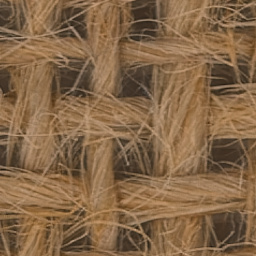

In [6]:
BASE_SIZE = 512
INNER_SIZE = 256
OFFSET = (BASE_SIZE - INNER_SIZE) // 2 

try:
    input_image = Image.open("juta2.jpg").convert("RGB")
    width, height = input_image.size

    left = (width - INNER_SIZE) / 2
    top = (height - INNER_SIZE) / 2
    right = (width + INNER_SIZE) / 2
    bottom = (height + INNER_SIZE) / 2
    input_image = input_image.crop((left, top, right, bottom))

except:
    print("Immagine non trovata.")
    input_image = Image.new("RGB", (INNER_SIZE, INNER_SIZE), "red")

input_image.save("prova_1cropped_2.png")
display(input_image)

In [7]:
width, height = input_image.size

left = (width - INNER_SIZE) / 2
top = (height - INNER_SIZE) / 2
right = (width + INNER_SIZE) / 2
bottom = (height + INNER_SIZE) / 2
small_texture = input_image.crop((left, top, right, bottom))

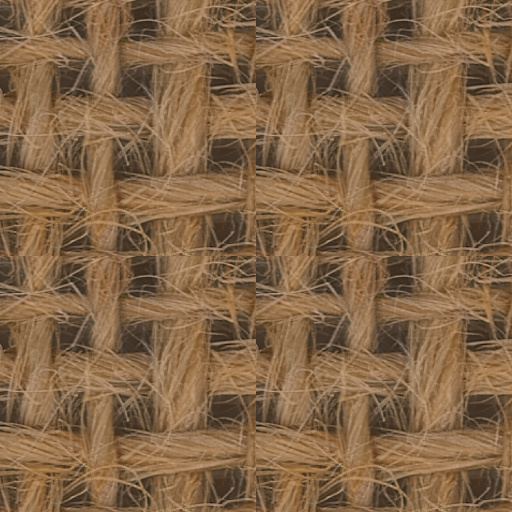

In [8]:
bg_hint = Image.new("RGB", (BASE_SIZE, BASE_SIZE), "white") 
canvas = bg_hint.copy()
canvas.paste(small_texture, (OFFSET, OFFSET))

mask = Image.new("L", (BASE_SIZE, BASE_SIZE), 255)
mask_center = Image.new("L", (INNER_SIZE, INNER_SIZE), 0)
mask.paste(mask_center, (OFFSET, OFFSET))
mask = mask.filter(ImageFilter.GaussianBlur(radius=10)) 

def create_guidance_image(source_img, target_size):
    tiled_bg = Image.new("RGB", (target_size, target_size))
    w, h = source_img.size
    tile_w, tile_h = 256, 256
    source_resized = source_img.resize((tile_w, tile_h))
    for i in range(0, target_size, tile_w):
        for j in range(0, target_size, tile_h):
            tiled_bg.paste(source_resized, (i, j))
    return tiled_bg


ip_adapter_image = create_guidance_image(small_texture, BASE_SIZE) 

ip_adapter_image.save("prova_2guidance_2.png")
display(ip_adapter_image)

100%|██████████| 50/50 [00:06<00:00,  7.45it/s]


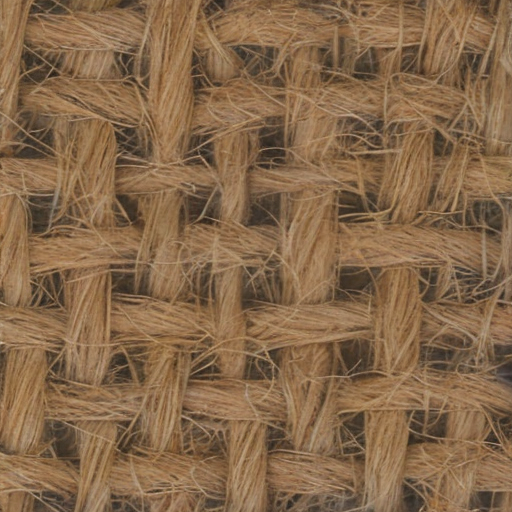

In [9]:
state["shift"] = (0, 0)
prompt = "Raw texture, regular pattern, flat colors, macro photography, close up, rough surface, hyperrealistic, top down view"
negative_prompt = "cartoon, drawing, painting, flat colors, vector, illustration, blurry, smooth, deformed, noisy"

output_base = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=canvas, 
    mask_image=mask,
    ip_adapter_image=ip_adapter_image,
    num_inference_steps=50,
    guidance_scale=6.5,
    callback_on_step_end=callback,
    callback_on_step_end_tensor_inputs=["latents", "mask", "masked_image_latents"]
).images[0]

display(output_base)

output_base.save("prova_3risultato_512_2.png")

--- Risultati Verifica Tileability ---
Discontinuità Orizzontale (0 = perfetta): 20.5495
Discontinuità Verticale (0 = perfetta): 16.9915


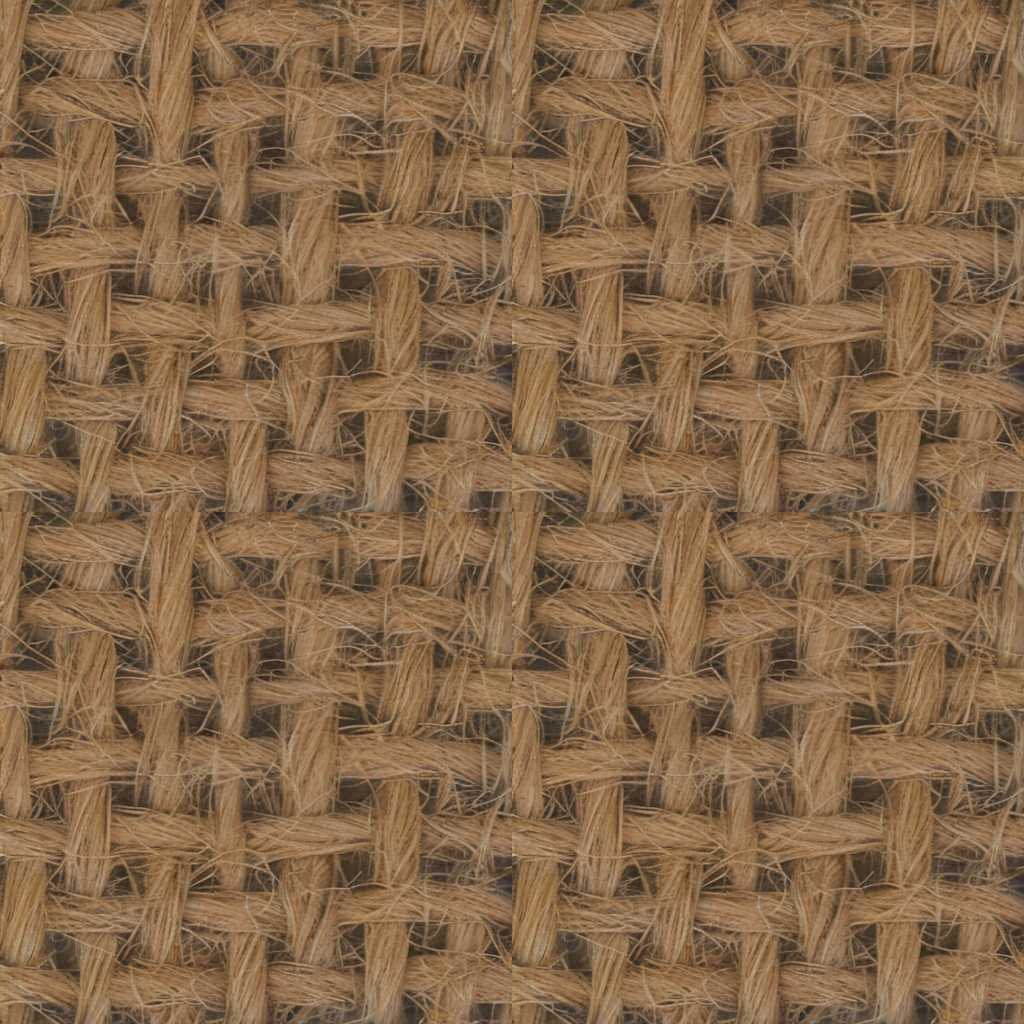

In [10]:
def verifica_tassellabilita(img_pil, n=2):
    """
    Visualizza l'immagine in una griglia n x n e calcola la differenza ai bordi.
    """
    w, h = img_pil.size
    
    # 1. Verifica Visiva: Crea una griglia (es. 2x2)
    # Se il rolling funziona, non dovresti vedere croci o linee al centro
    griglia = Image.new("RGB", (w * n, h * n))
    for i in range(n):
        for j in range(n):
            griglia.paste(img_pil, (i * w, j * h))
    
    # 2. Verifica Numerica: Calcolo dello "scalino" ai bordi
    img_np = np.array(img_pil).astype(np.float32)
    
    # Differenza media tra l'ultima colonna e la prima colonna (seam orizzontale)
    diff_h = np.mean(np.abs(img_np[:, -1, :] - img_np[:, 0, :]))
    
    # Differenza media tra l'ultima riga e la prima riga (seam verticale)
    diff_v = np.mean(np.abs(img_np[-1, :, :] - img_np[0, :, :]))
    
    print(f"--- Risultati Verifica Tileability ---")
    print(f"Discontinuità Orizzontale (0 = perfetta): {diff_h:.4f}")
    print(f"Discontinuità Verticale (0 = perfetta): {diff_v:.4f}")
    
    return griglia

griglia_risultato = verifica_tassellabilita(output_base)
griglia_risultato.save("test_tiling.png")
display(griglia_risultato)